## Testing Triskel-MC model selection with a small Gaussian problem 

	•	simulate data = white Gaussian noise + a random mixture of signals
	•	signals:
	•	Gaussian bumps: count ∈ {0,1,2} uniformly
	•	Tukey-window pulses: count ∈ {0,1} uniformly
	•	noise σ (“noise_sig”) ~ Uniform([1, Nsig_max])
	•	likelihood: d - \sum_j s_j(\theta_j) \sim \mathcal{N}(0,\sigma^2 I)

In [79]:

import matplotlib.pyplot  as plt
import numpy as np
from numpy.typing import ArrayLike

import pandas as pd
from dataclasses import dataclass

import jax
import jax.numpy as jnp
from jax import vmap, jit

from functools import partial

from typing import Callable, Optional


import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

plt.style.use(['seaborn-v0_8-ticks','seaborn-v0_8-deep'])

# %pylab inline

mpl.rcParams.update({'font.size': 16})
plt.rcParams['axes.grid'] = True
plt.rcParams["figure.figsize"] = (12,7)

%load_ext autoreload
%autoreload 2




import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

# plt.style.use(['seaborn-v0_8-ticks','seaborn-v0_8-deep'])

# %pylab inline

mpl.rcParams.update({'font.size': 16})
plt.rcParams['axes.grid'] = True
plt.rcParams["figure.figsize"] = (12,7)




%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:


def rng_from_seed(seed=0):
    return np.random.default_rng(seed)

def log_uniform(a, b, x):
    # log Uniform([a,b]) density for scalar/array x (returns -inf outside)
    x = np.asarray(x)
    out = np.full_like(x, -np.inf, dtype=float)
    m = (x >= a) & (x <= b)
    out[m] = -np.log(b - a)
    return out

In [81]:
def gaussian_signal(x, A, sigma, x0):
    return A * np.exp(-0.5 * ((x - x0) / sigma) ** 2)

# def tukey_window_1d(N, alpha):
#     """
#     Standard Tukey window of length N with taper fraction alpha in [0,1].
#     Returns w[n] for n=0..N-1.
#     """
#     if N <= 1:
#         return np.ones((N,), dtype=float)
#     alpha = float(alpha)
#     alpha = np.clip(alpha, 0.0, 1.0)
#     if alpha == 0.0:
#         return np.ones((N,), dtype=float)
#     if alpha == 1.0:
#         # Hann
#         n = np.arange(N)
#         return 0.5 * (1 - np.cos(2*np.pi*n/(N-1)))

#     n = np.arange(N)
#     w = np.ones((N,), dtype=float)
#     edge = int(np.floor(alpha*(N-1)/2.0))

#     # rising edge
#     if edge > 0:
#         n0 = np.arange(edge)
#         w[n0] = 0.5 * (1 + np.cos(np.pi*( (2*n0)/(alpha*(N-1)) - 1 )))
#         # falling edge
#         n1 = np.arange(N-edge, N)
#         k = n1 - (N-edge)
#         w[n1] = 0.5 * (1 + np.cos(np.pi*( (2*(N-1-n1))/(alpha*(N-1)) - 1 )))
#     return w

# def tukey_pulse(x, A, width, alpha, x0):
#     """
#     Tukey-window 'pulse' centered near x0 with total support ~width.
#     Implemented by placing a Tukey window on the nearest integer support.
#     """
#     width = float(width)
#     if width <= 0:
#         return np.zeros_like(x, dtype=float)

#     # integer support indices
#     half = 0.5 * width
#     i0 = int(np.floor(x0 - half))
#     i1 = int(np.ceil (x0 + half))
#     i0 = max(i0, 0)
#     i1 = min(i1, int(x[-1]) if np.all(np.isclose(np.diff(x), 1.0)) else len(x)-1)
#     # convert to index range in x-array (assume x = 0..L-1 integer grid)
#     i0 = max(i0, 0)
#     i1 = min(i1, len(x)-1)

#     N = i1 - i0 + 1
#     if N <= 0:
#         return np.zeros_like(x, dtype=float)

#     w = tukey_window_1d(N, alpha)
#     y = np.zeros_like(x, dtype=float)
#     y[i0:i1+1] = A * w
#     return y

### vectorisable RTukey signal


def tukey_pulse_vec(x, A, width, alpha, x0):
    """
    Vectorizable Tukey-like pulse.
    x: (L,)
    A,width,alpha,x0 can be scalars or arrays broadcastable to (B,1)
    returns (B,L) if A is (B,1), else (L,)
    """
    x = np.asarray(x, dtype=float)
    A = np.asarray(A, dtype=float)
    width = np.asarray(width, dtype=float)
    alpha = np.clip(np.asarray(alpha, dtype=float), 0.0, 1.0)
    x0 = np.asarray(x0, dtype=float)

    half = 0.5 * np.maximum(width, 1e-12)
    u = np.abs(x - x0) / half  # broadcast

    # support mask
    inside = (u < 1.0)

    # flat region threshold
    # when alpha=0 -> flat region is whole support; when alpha=1 -> no flat region (pure Hann-like)
    flat_thr = np.clip(1.0 - alpha, 0.0, 1.0)

    flat = inside & (u <= flat_thr)

    # taper: u in (flat_thr, 1)
    taper = inside & (~flat)

    y = np.zeros_like(u, dtype=float)

    # flat part = 1
    y = np.where(flat, 1.0, y)

    # taper part: cosine from 1 at u=flat_thr to 0 at u=1
    # t = (u - flat_thr)/(1-flat_thr) in (0,1)
    denom = np.maximum(1.0 - flat_thr, 1e-12)
    t = (u - flat_thr) / denom
    y = np.where(taper, 0.5 * (1.0 + np.cos(np.pi * t)), y)

    return A * y

In [82]:
@dataclass
class SimConfig:
    L: int = 512
    # noise sigma prior
    Nsig_max: float = 5.0

    # gaussian signal priors
    sig_min: float = 2.0
    sig_max: float = 10.0
    x_min: float = 50.0
    x_max: float = 500.0  # should be < L
    A_scale: float = 5.0  # amplitude prior is Uniform([0.3, A_scale*Nsig_max])
    A_min : float = 0.3

    # tukey priors
    w_min: float = 10.0
    w_max: float = 100.0
    alpha_min: float = 0.05
    alpha_max: float = 0.95



### Make a dataset



	•	noise_sig ~ U(1, Nsig_max)
	•	n_gauss ∈ {0,1,2} uniform
	•	n_tukey ∈ {0,1} uniform

In [83]:
def sample_ground_truth(rng, cfg: SimConfig):
    L = cfg.L
    x = np.arange(L, dtype=float)

    noise_sig = rng.uniform(1.0, cfg.Nsig_max)

    # counts
    n_gauss = int(rng.integers(0, 3))  # 0,1,2
    n_tukey = int(rng.integers(0, 2))  # 0,1
    print (f"Simulated truth: noise_sig={noise_sig:.3f}, n_gauss={n_gauss}, n_tukey={n_tukey}")

    gauss_params = []
    for _ in range(n_gauss):
        A = rng.uniform(cfg.A_min, cfg.A_scale * cfg.Nsig_max)
        sig = rng.uniform(cfg.sig_min, cfg.sig_max)
        x0 = rng.uniform(cfg.x_min, min(cfg.x_max, L - 1.0))
        gauss_params.append((A, sig, x0))

    tukey_params = []
    for _ in range(n_tukey):
        A = rng.uniform(cfg.A_min, cfg.A_scale * cfg.Nsig_max)
        w = rng.uniform(cfg.w_min, cfg.w_max)
        alpha = rng.uniform(cfg.alpha_min, cfg.alpha_max)
        x0 = rng.uniform(cfg.x_min, min(cfg.x_max, L - 1.0))
        tukey_params.append((A, w, alpha, x0))

    # build signal
    s = np.zeros(L, dtype=float)
    for (A, sig, x0) in gauss_params:
        s += gaussian_signal(x, A, sig, x0)

    # <<< CHANGED: use tukey_pulse_vec >>>
    for (A, w, alpha, x0) in tukey_params:
        s += tukey_pulse_vec(x, A, w, alpha, x0)

    # noise + data
    n = rng.normal(0.0, noise_sig, size=L)
    d = s + n

    truth = {
        "noise_sig": noise_sig,
        "gauss_params": gauss_params,
        "tukey_params": tukey_params,
        "signal": s,
        "noise": n,
        "data": d,
    }
    return x, truth

Simulated truth: noise_sig=2.775, n_gauss=1, n_tukey=1


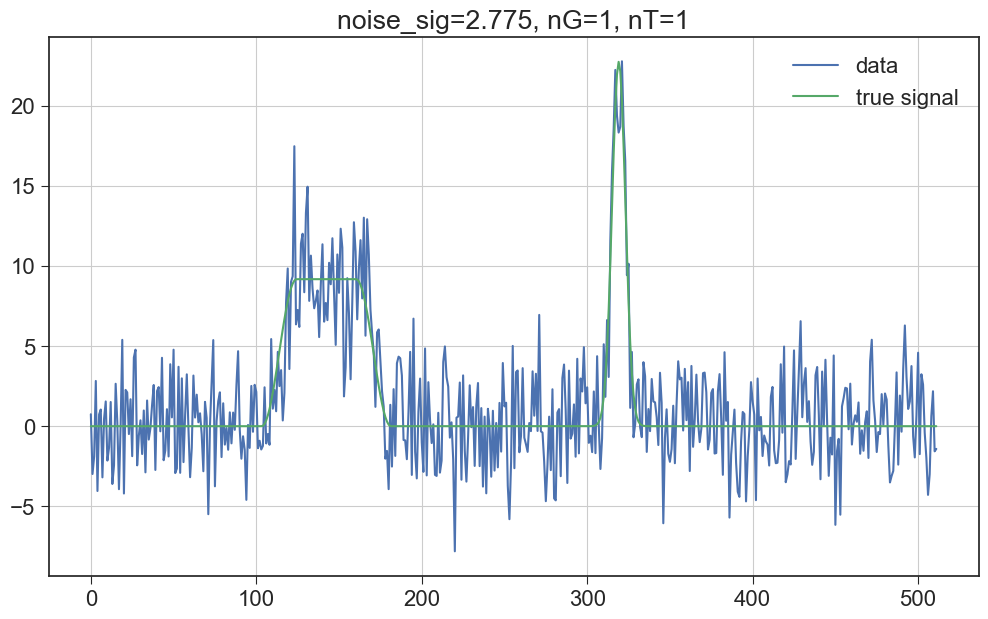

Gaussian ['A', 'sig', 'x0'] 
 [(22.730163241532242, 4.033996427990416, 319.0730406435657)]
Tukey ['A', 'w', 'alpha', 'x0'] 
 [(9.170346019074737, 78.0736255374391, 0.5387529757499896, 142.35259722491844)]


In [84]:
cfg = SimConfig(L=512, Nsig_max=5.0, x_max=507.0)
#7, 14, 15, 19, 21, 23, 29
rng = rng_from_seed(33)

x, truth = sample_ground_truth(rng, cfg)

plt.figure()
plt.plot(x, truth["data"], label="data")
plt.plot(x, truth["signal"], label="true signal")
plt.legend()
plt.title(f"noise_sig={truth['noise_sig']:.3f}, nG={len(truth['gauss_params'])}, nT={len(truth['tukey_params'])}")
plt.show()

Gaussian_params = ["A", "sig", "x0"]
Tukey_params = ["A", "w", "alpha", "x0"]

print ("Gaussian", Gaussian_params, "\n", truth["gauss_params"])
print ("Tukey", Tukey_params, "\n", truth["tukey_params"])

### Likelihood and log posterior pieces (Point 2)



We’ll represent a candidate model by:

	•	noise_sig (always present)
	•	gauss_params: list of up to 2 Gaussian components (active ones)
	•	tukey_params: list of up to 1 Tukey component (active ones)

In [85]:
def synthesize_signal(x, gauss_params, tukey_params):
    s = np.zeros_like(x, dtype=float)
    for (A, sig, x0) in gauss_params:
        s += gaussian_signal(x, A, sig, x0)
    for (A, w, alpha, x0) in tukey_params:
        s += tukey_pulse_vec(x, A, w, alpha, x0)
    return s

def loglik_gaussian_iid(d, s, noise_sig):
    """
    d = s + n, n ~ N(0, noise_sig^2 I)
    """
    noise_sig = float(noise_sig)
    if noise_sig <= 0 or not np.isfinite(noise_sig):
        return -np.inf
    r = d - s
    L = r.size
    return -0.5 * (np.sum(r*r) / (noise_sig**2) + L*np.log(2*np.pi*noise_sig**2))

In [86]:
def logprior_noise(noise_sig, cfg: SimConfig):
    return float(log_uniform(1.0, cfg.Nsig_max, noise_sig))

def logprior_gauss_component(A, sig, x0, cfg: SimConfig):
    lp = 0.0
    lp += float(log_uniform(cfg.A_min, cfg.A_scale*cfg.Nsig_max, A))
    lp += float(log_uniform(cfg.sig_min, cfg.sig_max, sig))
    lp += float(log_uniform(cfg.x_min, min(cfg.x_max, cfg.L-1.0), x0))
    return lp if np.isfinite(lp) else -np.inf

def logprior_tukey_component(A, w, alpha, x0, cfg: SimConfig):
    lp = 0.0
    lp += float(log_uniform(cfg.A_min, cfg.A_scale*cfg.Nsig_max, A))
    lp += float(log_uniform(cfg.w_min, cfg.w_max, w))
    lp += float(log_uniform(cfg.alpha_min, cfg.alpha_max, alpha))
    lp += float(log_uniform(cfg.x_min, min(cfg.x_max, cfg.L-1.0), x0))
    return lp

def logprior_model(noise_sig, gauss_params, tukey_params, cfg: SimConfig):
    lp = logprior_noise(noise_sig, cfg)
    for (A, sig, x0) in gauss_params:
        lp += logprior_gauss_component(A, sig, x0, cfg)
    for (A, w, alpha, x0) in tukey_params:
        lp += logprior_tukey_component(A, w, alpha, x0, cfg)
    return float(lp)

In [87]:
print ("noise prior", logprior_noise(truth["noise_sig"], cfg))
for i, (A, sig, x0) in enumerate(truth["gauss_params"]):
    print (f"Gaussian {i} prior", logprior_gauss_component(A, sig, x0, cfg))
for i, (A, w, alpha, x0) in enumerate(truth["tukey_params"]):
    print (f"Tukey {i} prior", logprior_tukey_component(A, w, alpha, x0, cfg))

noise prior -1.3862943611198906
Gaussian 0 prior -11.410928176207973
Tukey 0 prior -13.725935789200575


In [88]:
def logposterior(d, x, noise_sig, gauss_params, tukey_params, cfg: SimConfig):
    s = synthesize_signal(x, gauss_params, tukey_params)
    ll = loglik_gaussian_iid(d, s, noise_sig)
    if not np.isfinite(ll):
        return -np.inf
    lp = logprior_model(noise_sig, gauss_params, tukey_params, cfg)
    return lp + ll

In [89]:
# print ("log posteriror", logposterior(truth["data"], x, truth["noise_sig"], truth["gauss_params"], truth["tukey_params"], cfg))

d = truth["data"]

lp_true = logposterior(
    d, x,
    truth["noise_sig"],
    truth["gauss_params"],
    truth["tukey_params"],
    cfg
)

lp_noise_only = logposterior(
    d, x,
    truth["noise_sig"],
    [], [],  # no signals
    cfg
)

print ("log posterior (true model)", lp_true)
print ("log posterior (noise only)", lp_noise_only) 

log posterior (true model) -1251.8000142901292
log posterior (noise only) -1731.5291160325082


### Making necessary functions

In [96]:
SLOT_DIM  = np.array([1,3,3,4], dtype=np.int32)
KMAX, DMAX = 4, 4

TYPE_NOISE = 0
TYPE_GAUSS = 1
TYPE_TUKEY = 2
SLOT_TYPE = np.array([TYPE_NOISE, TYPE_GAUSS, TYPE_GAUSS, TYPE_TUKEY], dtype=np.int32)

MUST_BE_ON = np.array([True, False, False, False], dtype=bool)
CAN_TOGGLE = np.array([False, True, True, True], dtype=bool)

In [91]:


# def init_product_space_state(rng, C, W, cfg: SimConfig):
#     phi = np.zeros((C,W,KMAX,DMAX), dtype=np.float64)
#     m   = np.zeros((C,W,KMAX), dtype=bool)

#     # noise always on
#     phi[:,:,0,0] = rng.uniform(1.0, cfg.Nsig_max, size=(C,W))
#     m[:,:,0] = True

#     # start with no signals (can change later)
#     return phi, m

In [ ]:


# def log_prior_phi_np(phi_j: np.ndarray, type_j: int, cfg: SimConfig) -> float:
#     """
#     Prior for ACTIVE slot parameters.
#     phi_j: shape (dj,) (already sliced to slot_dim[j])
#     type_j: int label for that slot
#     """
#     phi_j = np.asarray(phi_j, dtype=float)
#     t = int(type_j)

#     if t == TYPE_NOISE:
#         noise_sig = float(phi_j[0])
#         return float(log_uniform(1.0, cfg.Nsig_max, noise_sig))

#     elif t == TYPE_GAUSS:
#         A   = float(phi_j[0])
#         sig = float(phi_j[1])
#         x0  = float(phi_j[2])
#         lp = 0.0
#         lp += float(log_uniform(cfg.A_min, cfg.A_scale * cfg.Nsig_max, A))
#         lp += float(log_uniform(cfg.sig_min, cfg.sig_max, sig))
#         lp += float(log_uniform(cfg.x_min, min(cfg.x_max, cfg.L - 1.0), x0))
#         return float(lp)

#     elif t == TYPE_TUKEY:
#         A     = float(phi_j[0])
#         width = float(phi_j[1])
#         alpha = float(phi_j[2])
#         x0    = float(phi_j[3])
#         lp = 0.0
#         lp += float(log_uniform(cfg.A_min, cfg.A_scale * cfg.Nsig_max, A))
#         lp += float(log_uniform(cfg.w_min, cfg.w_max, width))
#         lp += float(log_uniform(cfg.alpha_min, cfg.alpha_max, alpha))
#         lp += float(log_uniform(cfg.x_min, min(cfg.x_max, cfg.L - 1.0), x0))
#         return float(lp)

#     else:
#         # unknown type => forbid
#         return -np.inf


def log_pseudo_phi_np(phi_j: np.ndarray, type_j: int, cfg: SimConfig) -> float:
    """
    Pseudo-prior for INACTIVE slot parameters.
    For the toy problem, simplest is: use the SAME distribution as the prior.
    (That makes births/deaths easier to debug and still valid.)
    """
    return log_prior_phi_np(phi_j, type_j, cfg)



#  builder
def make_log_prior_phi(cfg: SimConfig):
    def log_prior_phi_np(phi_j: np.ndarray, type_j: int) -> float:
        phi_j = np.asarray(phi_j, dtype=float)
        t = int(type_j)

        if t == TYPE_NOISE:
            noise_sig = float(phi_j[0])
            return float(log_uniform(1.0, cfg.Nsig_max, noise_sig))

        elif t == TYPE_GAUSS:
            A, sig, x0 = map(float, phi_j[:3])
            lp = 0.0
            lp += float(log_uniform(cfg.A_min, cfg.A_scale * cfg.Nsig_max, A))
            lp += float(log_uniform(cfg.sig_min, cfg.sig_max, sig))
            lp += float(log_uniform(cfg.x_min, min(cfg.x_max, cfg.L - 1.0), x0))
            return float(lp)

        elif t == TYPE_TUKEY:
            A, width, alpha, x0 = map(float, phi_j[:4])
            lp = 0.0
            lp += float(log_uniform(cfg.A_min, cfg.A_scale * cfg.Nsig_max, A))
            lp += float(log_uniform(cfg.w_min, cfg.w_max, width))
            lp += float(log_uniform(cfg.alpha_min, cfg.alpha_max, alpha))
            lp += float(log_uniform(cfg.x_min, min(cfg.x_max, cfg.L - 1.0), x0))
            return float(lp)

        return -np.inf

    return log_prior_phi_np

def make_log_pseudo_phi(cfg: SimConfig):
    log_prior_phi = make_log_prior_phi(cfg)
    def log_pseudo_phi_np(phi_j: np.ndarray, type_j: int) -> float:
        return log_prior_phi(phi_j, type_j)
    return log_pseudo_phi_np



log_prior_phi_np = make_log_prior_phi(cfg)
log_pseudo_phi_np = make_log_pseudo_phi(cfg)

In [93]:
def sample_from_prior_for_type(rng, type_j: int, cfg: SimConfig):
    if type_j == TYPE_NOISE:
        out = np.zeros(DMAX, dtype=float)
        out[0] = rng.uniform(1.0, cfg.Nsig_max)
        return out
    elif type_j == TYPE_GAUSS:
        out = np.zeros(DMAX, dtype=float)
        out[0] = rng.uniform(cfg.A_min, cfg.A_scale * cfg.Nsig_max)
        out[1] = rng.uniform(cfg.sig_min, cfg.sig_max)
        out[2] = rng.uniform(cfg.x_min, min(cfg.x_max, cfg.L - 1.0))
        return out
    elif type_j == TYPE_TUKEY:
        out = np.zeros(DMAX, dtype=float)
        out[0] = rng.uniform(cfg.A_min, cfg.A_scale * cfg.Nsig_max)
        out[1] = rng.uniform(cfg.w_min, cfg.w_max)
        out[2] = rng.uniform(cfg.alpha_min, cfg.alpha_max)
        out[3] = rng.uniform(cfg.x_min, min(cfg.x_max, cfg.L - 1.0))
        return out
    else:
        raise ValueError(f"Unknown slot type {type_j}")
    

def init_product_space_state(rng, C, W, cfg: SimConfig):
    phi = np.zeros((C, W, KMAX, DMAX), dtype=np.float64)
    m   = np.zeros((C, W, KMAX), dtype=bool)

    for j in range(KMAX):
        t = int(SLOT_TYPE[j])
        for c in range(C):
            for w in range(W):
                phi[c, w, j, :] = sample_from_prior_for_type(rng, t, cfg)

    # noise always on
    m[:, :, 0] = True

    # start with all signal slots off
    return phi, m
    

def pack_state_from_components(rng, noise_sig, gauss_params, tukey_params, cfg: SimConfig):
    phi = np.zeros((KMAX, DMAX), dtype=np.float64)
    m   = np.zeros((KMAX,), dtype=bool)

    if len(gauss_params) > 2:
        raise ValueError("At most 2 Gaussian components supported")
    if len(tukey_params) > 1:
        raise ValueError("At most 1 Tukey component supported")
    
    # initialize every slot with a valid prior/pseudo-prior draw
    for j in range(KMAX):
        phi[j, :] = sample_from_prior_for_type(rng, int(SLOT_TYPE[j]), cfg)

    # noise always present
    phi[0,0] = noise_sig
    m[0] = True

    # up to two gaussians -> slots 1,2
    for j, (A,sig,x0) in enumerate(gauss_params, start=1):
        phi[j,0:3] = (A, sig, x0)
        m[j] = True

    # at most one tukey -> slot 3
    if len(tukey_params) == 1:
        A,w,a,x0 = tukey_params[0]
        phi[3,0:4] = (A,w,a,x0)
        m[3] = True

    return phi, m


phi_true, m_true = pack_state_from_components(
    rng=rng,
    noise_sig=truth["noise_sig"],
    gauss_params=truth["gauss_params"],
    tukey_params=truth["tukey_params"],
    cfg=cfg,
)

print ('phi_true:\n', phi_true)
print ('m_true:\n', m_true)

phi_true:
 [[  2.77456895   0.           0.           0.        ]
 [ 22.73016324   4.03399643 319.07304064   0.        ]
 [ 17.10323536   8.76284283 298.92291921   0.        ]
 [  9.17034602  78.07362554   0.53875298 142.35259722]]
m_true:
 [ True  True False  True]


In [ ]:
def make_log_lik_masked(d: np.ndarray, x: np.ndarray):
    d = np.asarray(d, dtype=float)
    x = np.asarray(x, dtype=float)

    def log_lik_masked(
        phi_one: np.ndarray,
        m_one: np.ndarray,
        rest_one: Optional[np.ndarray],
        slot_dim: np.ndarray,
        slot_type: np.ndarray,
    ) -> float:
        """
        phi_one:   (KMAX, DMAX)
        m_one:     (KMAX,)
        rest_one:  ignored for this toy problem
        slot_dim:  (KMAX,)
        slot_type: (KMAX,)
        """

        phi_one = np.asarray(phi_one, dtype=float)
        m_one = np.asarray(m_one, dtype=bool)
        slot_dim = np.asarray(slot_dim, dtype=np.int32)
        slot_type = np.asarray(slot_type, dtype=np.int32)

        ### sanity checks (not really needed if you're sane)
        if phi_one.ndim != 2:
            raise ValueError(f"phi_one must have shape (KMAX, DMAX), got {phi_one.shape}")
        if m_one.ndim != 1:
            raise ValueError(f"m_one must have shape (KMAX,), got {m_one.shape}")

        Kmax = phi_one.shape[0]
        if m_one.shape != (Kmax,):
            raise ValueError(f"m_one must have shape {(Kmax,)}, got {m_one.shape}")
        if slot_dim.shape != (Kmax,):
            raise ValueError(f"slot_dim must have shape {(Kmax,)}, got {slot_dim.shape}")
        if slot_type.shape != (Kmax,):
            raise ValueError(f"slot_type must have shape {(Kmax,)}, got {slot_type.shape}")

        s = np.zeros_like(x, dtype=float)
        noise_sig = None

        for j in range(Kmax):
            dj = int(slot_dim[j])
            tj = int(slot_type[j])
            pars = phi_one[j, :dj]

            if tj == TYPE_NOISE:
                # noise slot must define the likelihood noise sigma
                if not m_one[j]:
                    return -np.inf
                noise_sig = float(pars[0])

            elif not m_one[j]:
                # inactive signal slot contributes nothing
                continue

            elif tj == TYPE_GAUSS:
                A, sig, x0 = map(float, pars[:3])
                s += gaussian_signal(x, A, sig, x0)

            elif tj == TYPE_TUKEY:
                A, w, alpha, x0 = map(float, pars[:4])
                s += tukey_pulse_vec(x, A, w, alpha, x0)

            else:
                return -np.inf

        if noise_sig is None:
            return -np.inf

        return float(loglik_gaussian_iid(d, s, noise_sig))

    return log_lik_masked


### specific to the problem, not the general framework

# def make_log_lik_masked(d: np.ndarray, x: np.ndarray):
#     d = np.asarray(d, dtype=float)
#     x = np.asarray(x, dtype=float)

#     def log_lik_masked(
#         phi_one: np.ndarray,
#         m_one: np.ndarray,
#         rest_one: Optional[np.ndarray],
#         slot_dim: np.ndarray,
#         slot_type: np.ndarray,
#     ) -> float:
#         phi_one = np.asarray(phi_one, dtype=float)
#         m_one = np.asarray(m_one, dtype=bool)

#         if not m_one[0]:
#             return -np.inf

#         noise_sig = float(phi_one[0, 0])
#         s = np.zeros_like(x, dtype=float)

#         if m_one[1]:
#             s += gaussian_signal(x, phi_one[1, 0], phi_one[1, 1], phi_one[1, 2])

#         if m_one[2]:
#             s += gaussian_signal(x, phi_one[2, 0], phi_one[2, 1], phi_one[2, 2])

#         if m_one[3]:
#             s += tukey_pulse_vec(x, phi_one[3, 0], phi_one[3, 1], phi_one[3, 2], phi_one[3, 3])

#         return float(loglik_gaussian_iid(d, s, noise_sig))

#     return log_lik_masked

log_lik_masked = make_log_lik_masked(d=truth["data"], x=x)

In [95]:
log_lik_masked(phi_true, m_true, None, SLOT_DIM, SLOT_TYPE)

-1225.2768559636008

In [98]:
def make_log_p_mask_np(p_on_gauss=0.5, p_on_tukey=0.5):
    ## probability of a slot being ON for each type (for the prior on the mask)
    log_p_on_gauss = np.log(p_on_gauss)
    log_p_off_gauss = np.log(1.0 - p_on_gauss)

    log_p_on_tukey = np.log(p_on_tukey)
    log_p_off_tukey = np.log(1.0 - p_on_tukey)

    def log_p_mask_np(
        m: np.ndarray,
        slot_type: np.ndarray,
        must_be_on: Optional[np.ndarray],
        can_toggle: Optional[np.ndarray],
    ) -> np.ndarray:
        """
        m:         (C, W, KMAX) bool
        slot_type: (KMAX,)
        must_be_on:(KMAX,) bool or None
        can_toggle:(KMAX,) bool or None

        returns:   (C, W)
        """
        m = np.asarray(m, dtype=bool)
        slot_type = np.asarray(slot_type, dtype=np.int32)

        C, W, Kmax = m.shape

        if slot_type.shape != (Kmax,):
            raise ValueError(f"slot_type must have shape {(Kmax,)}, got {slot_type.shape}")

        if must_be_on is None:
            must_be_on = np.zeros(Kmax, dtype=bool)
        else:
            must_be_on = np.asarray(must_be_on, dtype=bool)
            if must_be_on.shape != (Kmax,):
                raise ValueError(f"must_be_on must have shape {(Kmax,)}, got {must_be_on.shape}")

        if can_toggle is None:
            can_toggle = np.ones(Kmax, dtype=bool)
        else:
            can_toggle = np.asarray(can_toggle, dtype=bool)
            if can_toggle.shape != (Kmax,):
                raise ValueError(f"can_toggle must have shape {(Kmax,)}, got {can_toggle.shape}")

        out = np.zeros((C, W), dtype=np.float64)

        for j in range(Kmax):
            mj = m[:, :, j]
            tj = int(slot_type[j])

            # hard constraints
            if must_be_on[j]:
                if np.any(~mj):
                    return np.full((C, W), -np.inf, dtype=np.float64)
                continue

            # if a slot cannot toggle, its mask is structurally fixed by initialization/state design.
            # We give it no additional prior contribution here.
            if not can_toggle[j]:
                continue

            if tj == TYPE_NOISE:
                # if noise is not marked must_be_on, still require it on
                if np.any(~mj):
                    return np.full((C, W), -np.inf, dtype=np.float64)
                continue

            elif tj == TYPE_GAUSS:
                out += np.where(mj, log_p_on_gauss, log_p_off_gauss)

            elif tj == TYPE_TUKEY:
                out += np.where(mj, log_p_on_tukey, log_p_off_tukey)

            else:
                return np.full((C, W), -np.inf, dtype=np.float64)

        return out

    return log_p_mask_np

log_p_mask_np = make_log_p_mask_np(
    p_on_gauss=0.5,
    p_on_tukey=0.5,
)

log_p_mask_np(m_true[None, None, :], SLOT_TYPE, MUST_BE_ON, CAN_TOGGLE)

array([[-2.07944154]])

In [100]:
def uniform_density(a, b, x):
    x = np.asarray(x)
    out = np.zeros_like(x, dtype=float)
    m = (x >= a) & (x <= b)
    out[m] = 1.0 / (b - a)
    return out


# •	phi_j: shape (C, W, dj) for the slot being evaluated
# •	m_ctx: shape (C, W, KMAX) mask context
# •	phi_full: shape (C, W, KMAX, DMAX) full state
# •	rest: optional extra state
# •	keyword slot
# •	keyword slot_type

def make_qb_density_np(cfg: SimConfig):
    x0_hi = min(cfg.x_max, cfg.L - 1.0)

    def qb_density_np(
        phi_j: np.ndarray,
        m_ctx: np.ndarray,
        phi_full: np.ndarray,
        rest: Optional[np.ndarray],
        *,
        slot: int,
        slot_type: int,
    ) -> np.ndarray:
        """
        Birth proposal density q_b for the parameters of a single slot.

        Parameters
        ----------
        phi_j : (C, W, dj)
            Parameters of the slot being evaluated, sliced to slot_dim[slot].
        m_ctx : (C, W, KMAX)
            Context mask. Unused here.
        phi_full : (C, W, KMAX, DMAX)
            Full state. Unused here.
        rest : optional
            Unused here.
        slot : int
            Slot index. Unused here except for debugging.
        slot_type : int
            Semantic slot type.

        Returns
        -------
        q : (C, W)
            Proposal density in ordinary density scale.
        """
        phi_j = np.asarray(phi_j, dtype=float)
        t = int(slot_type)

        if phi_j.ndim != 3:
            raise ValueError(f"phi_j must have shape (C,W,dj), got {phi_j.shape}")

        if t == TYPE_NOISE:
            # Normally irrelevant because noise is not toggleable,
            # but define it consistently anyway.
            return uniform_density(1.0, cfg.Nsig_max, phi_j[:, :, 0])

        if t == TYPE_GAUSS:
            q = np.ones(phi_j.shape[:2], dtype=float)
            q *= uniform_density(cfg.A_min, cfg.A_scale * cfg.Nsig_max, phi_j[:, :, 0])
            q *= uniform_density(cfg.sig_min, cfg.sig_max, phi_j[:, :, 1])
            q *= uniform_density(cfg.x_min, x0_hi, phi_j[:, :, 2])
            return q

        if t == TYPE_TUKEY:
            q = np.ones(phi_j.shape[:2], dtype=float)
            q *= uniform_density(cfg.A_min, cfg.A_scale * cfg.Nsig_max, phi_j[:, :, 0])
            q *= uniform_density(cfg.w_min, cfg.w_max, phi_j[:, :, 1])
            q *= uniform_density(cfg.alpha_min, cfg.alpha_max, phi_j[:, :, 2])
            q *= uniform_density(cfg.x_min, x0_hi, phi_j[:, :, 3])
            return q

        return np.zeros(phi_j.shape[:2], dtype=float)

    return qb_density_np

qb_density_np = make_qb_density_np(cfg)


In [101]:
phi_test = np.zeros((2, 3, 3))
phi_test[:, :, 0] = 1.0    # A
phi_test[:, :, 1] = 5.0    # sig
phi_test[:, :, 2] = 200.0  # x0

m_ctx = np.zeros((2, 3, KMAX), dtype=bool)
phi_full = np.zeros((2, 3, KMAX, DMAX), dtype=float)

q = qb_density_np(phi_test, m_ctx, phi_full, None, slot=1, slot_type=TYPE_GAUSS)
print(q.shape, q)

(2, 3) [[1.10738047e-05 1.10738047e-05 1.10738047e-05]
 [1.10738047e-05 1.10738047e-05 1.10738047e-05]]


In [103]:
# ---------------------------------------------------------------------
# 6. Build initial PSState
# ---------------------------------------------------------------------
# Adjust these imports to your actual repository paths
from triskel_mc.states import PSState
from triskel_mc.runner import run_ct_mcmc
from triskel_mc.birth_death import make_batched_loglik_masked_np


cfg = SimConfig(L=512, Nsig_max=5.0, x_max=507.0)
rng = rng_from_seed(4)

x, truth = sample_ground_truth(rng, cfg)
d = truth["data"]

log_prior_phi_np = make_log_prior_phi(cfg)
log_pseudo_phi_np = make_log_pseudo_phi(cfg)
qb_density_np = make_qb_density_np(cfg)

log_lik_masked = make_log_lik_masked(d=d, x=x)
batched_ll_masked = make_batched_loglik_masked_np(log_lik_masked)

log_p_mask_np = make_log_p_mask_np(
    p_on_gauss=0.5,
    p_on_tukey=0.5,
)

C = 4          # number of temperatures
W = 16         # walkers per temperature

phi0, m0, rest0 = init_product_space_state(rng, C=C, W=W, cfg=cfg)

ImportError: cannot import name 'make_batched_loglik_masked_np' from 'triskel_mc.birth_death' (/opt/anaconda3/envs/globalfit/lib/python3.13/site-packages/triskel_mc/birth_death.py)

In [26]:

from typing import Optional

# Example type ids (you can choose any ints)
TYPE_NOISE = 0
TYPE_GAUSS = 1
TYPE_TUKEY = 2

def log_prior_phi_np(phi_j: np.ndarray, type_j: int, cfg) -> float:
    """
    Prior for ACTIVE slot parameters.
    phi_j: shape (dj,) (already sliced to slot_dim[j])
    type_j: int label for that slot
    """
    phi_j = np.asarray(phi_j, dtype=float)
    t = int(type_j)

    if t == TYPE_NOISE:
        noise_sig = float(phi_j[0])
        return float(log_uniform(1.0, cfg.Nsig_max, noise_sig))

    elif t == TYPE_GAUSS:
        A   = float(phi_j[0])
        sig = float(phi_j[1])
        x0  = float(phi_j[2])
        lp = 0.0
        lp += float(log_uniform(0.0, cfg.A_scale * cfg.Nsig_max, A))
        lp += float(log_uniform(cfg.sig_min, cfg.sig_max, sig))
        lp += float(log_uniform(cfg.x_min, min(cfg.x_max, cfg.L - 1.0), x0))
        return float(lp)

    elif t == TYPE_TUKEY:
        A     = float(phi_j[0])
        width = float(phi_j[1])
        alpha = float(phi_j[2])
        x0    = float(phi_j[3])
        lp = 0.0
        lp += float(log_uniform(0.0, cfg.A_scale * cfg.Nsig_max, A))
        lp += float(log_uniform(cfg.w_min, cfg.w_max, width))
        lp += float(log_uniform(cfg.alpha_min, cfg.alpha_max, alpha))
        lp += float(log_uniform(cfg.x_min, min(cfg.x_max, cfg.L - 1.0), x0))
        return float(lp)

    else:
        # unknown type => forbid
        return -np.inf


def log_pseudo_phi_np(phi_j: np.ndarray, type_j: int, cfg) -> float:
    """
    Pseudo-prior for INACTIVE slot parameters.
    For the toy problem, simplest is: use the SAME distribution as the prior.
    (That makes births/deaths easier to debug and still valid.)
    """
    return log_prior_phi_np(phi_j, type_j, cfg)

In [27]:
def log_p_mask_np(
    m: np.ndarray,                    # (C,W,Kmax) bool
    slot_type: np.ndarray,            # (Kmax,) int labels (not necessarily used here)
    must_be_on: Optional[np.ndarray], # (Kmax,) bool or None
    can_toggle: Optional[np.ndarray], # (Kmax,) bool or None
) -> np.ndarray:
    """
    Returns log p(m) for each (C,W). Shape (C,W).

    This version is:
      - hard constraints only (invalid masks -> -inf)
      - otherwise uniform over masks (0.0)
    """
    m = np.asarray(m, dtype=bool)
    C, W, Kmax = m.shape

    lp = np.zeros((C, W), dtype=np.float64)

    # must_be_on: enforce those slots are True
    if must_be_on is not None:
        must_be_on = np.asarray(must_be_on, dtype=bool)
        if must_be_on.shape != (Kmax,):
            raise ValueError(f"must_be_on must have shape (Kmax,), got {must_be_on.shape}")
        ok = np.all(m[..., must_be_on], axis=-1)  # (C,W)
        lp = np.where(ok, lp, -np.inf)

    # can_toggle: if False, the slot must never change from its initial convention.
    # For a generic mask prior, the safest is: if can_toggle[j]==False then slot is REQUIRED ON.
    # (If you need "fixed OFF", add another array e.g. must_be_off.)
    if can_toggle is not None:
        can_toggle = np.asarray(can_toggle, dtype=bool)
        if can_toggle.shape != (Kmax,):
            raise ValueError(f"can_toggle must have shape (Kmax,), got {can_toggle.shape}")
        fixed = ~can_toggle
        if np.any(fixed):
            ok = np.all(m[..., fixed], axis=-1)  # require fixed slots ON
            lp = np.where(ok, lp, -np.inf)

    return lp

In [ ]:
# Later:
# Kmax = 4
# slot_dim  = [1, 3, 3, 4]
# slot_type = (user-defined labels like ["noise","gauss","gauss","tukey"] or ints)
# must_be_on = [True, False, False, False]
# can_toggle = [False, True, True, True]  # noise not toggled

print("Sampler integration will come next once we update Triskel-MC for typed slots + constraints.")